In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error,r2_score
import pandas as pnd


<h1 style="color: red;">Section 1: Data</h1>

<h2>1) Préparation de données</h2>

In [2]:
np.random.seed(44) #à chaque exécution,générer le même dataset de manière aléatoire
# Coefficients
a1, a2, b = 2, 3, 5  # y = 2*X1 + 3*X2 + 5 + bruit
nombre_points = 100 # Nombre de points
# Génération des deux features (X1 et X2)
X1 = np.random.rand(nombre_points) * 10
X2 = np.random.rand(nombre_points) * 10
# Empilement des features dans une seule matrice (shape: (100, 2))
X = np.column_stack((X1, X2))
# Génération du bruit
bruit = np.random.randn(nombre_points) * 2  # Bruit
# Calcul de la target
y = a1 * X1 + a2 * X2 + b + bruit

#spilt data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=23)


**Importance du decoupage train/test**  
Le training set sert a apprendre les parametres du modele. Le test set sert a mesurer la capacite de generalisation sur des donnees jamais vues. Cette separation evite de surestimer les performances.


<h1 style="color: red;">Section 2: Neural network avec tensorflow</h1>

In [3]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

<h2>2) Modèle de réseau de neurones</h2>

**Architecture choisie**  
- Inputs du reseau : `X1` et `X2`, donc 2 entrees.  
- Couche de sortie : 1 neurone, car la target `y` est une valeur continue.  
- Activation de sortie : `linear`, adaptee a la regression.


In [4]:
model_nn = Sequential()
output_layer = Dense(1, input_shape=(X_train.shape[1],), activation='linear')
model_nn.add(output_layer)
model_nn.compile(optimizer='adam', loss='mse', metrics=['mse'])
history = model_nn.fit(X_train, y_train, epochs=100, verbose=0)


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model_nn.summary()
print("Nombre total de parametres :", model_nn.count_params())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (48.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8 (36.00 B)

Nombre total de parametres : 3


**Role de `fit`**  
La fonction `fit` entraine le modele sur le training set. A chaque epoch, elle calcule les predictions, l'erreur, puis met a jour les poids et le biais pour minimiser la loss.

**Calcul du nombre de parametres**  
Avec 2 inputs et 1 neurone de sortie sans couche cachee, on a :
- 2 poids
- 1 biais  

Donc le modele contient `3` parametres entrainables.

**Quand faire du tuning / de la regularisation**  
Le tuning devient utile si le modele sous-apprend ou sur-apprend. La regularisation est importante quand le modele devient trop sensible au bruit ou quand l'ecart entre train et test devient grand.


<h2>3) Prédiction en utilisant le modèle</h2>

In [6]:
yhat_nn = model_nn.predict(X_test, verbose=0)


In [7]:
yhat_nn=yhat_nn.flatten()

In [8]:
W_nn, bias_nn = model_nn.layers[0].get_weights()

# Afficher les poids et biais
print("Poids :", W_nn.flatten())
print("Biais :", bias_nn)

Poids : [1.1331196  0.78489304]
Biais : [0.2904571]


In [9]:
yhat_manual = (X_test @ W_nn + bias_nn).flatten()
print("Premieres predictions manuelles :", yhat_manual[:5])
print("Predictions identiques a predict :", np.allclose(yhat_nn, yhat_manual))


Premieres predictions manuelles : [14.90165839 14.71515041 11.79344118 11.85133349 13.63190122]
Predictions identiques a predict : True


<h2>4) Evaluation du modèle</h2>

Train - MSE: 420.39223718364445 R2: -4.108155104553917
Test  - MSE: 487.46883070772617 R2: -3.3277158845741086


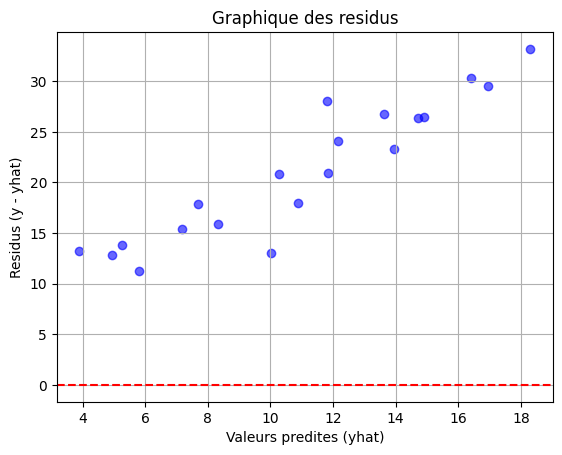

In [10]:
yhat_train_nn = model_nn.predict(X_train, verbose=0).flatten()
mse_train_nn = mean_squared_error(y_train, yhat_train_nn)
r2_train_nn = r2_score(y_train, yhat_train_nn)
mse_test_nn = mean_squared_error(y_test, yhat_nn)
r2_test_nn = r2_score(y_test, yhat_nn)

print("Train - MSE:", mse_train_nn, "R2:", r2_train_nn)
print("Test  - MSE:", mse_test_nn, "R2:", r2_test_nn)

# Tracé des résidus sur le test set
plt.scatter(yhat_nn, y_test - yhat_nn, color='blue', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valeurs predites (yhat)")
plt.ylabel("Residus (y - yhat)")
plt.title("Graphique des residus")
plt.grid(True)
plt.show()


**Interpretation des residus**  
Si les residus sont repartis aleatoirement autour de `0`, le modele capture correctement la relation lineaire. Si une structure apparait, cela peut signaler un biais de modele ou une relation non lineaire.

**Pourquoi evaluer sur train et test**  
Evaluer sur train montre ce que le modele a appris. Evaluer sur test montre sa capacite de generalisation. Comparer les deux permet de detecter sous-apprentissage et surapprentissage.


<h1>From scratch</h1>


<h1 style="color: red;"> Section 3 :Régression linéaire from scratch </h1>


<h2>Modèle (version1) de régression linéaire from scratch avec utilisation des matrices</h2>


**Pourquoi developper le modele from scratch**  
Cette partie permet de comprendre explicitement les etapes mathematiques : prediction, calcul de l'erreur, gradients, puis mise a jour des parametres.

**Etapes principales**  
1. Initialiser `W` et `b`.  
2. Calculer `y_pred = X @ W + b`.  
3. Calculer l'erreur.  
4. Calculer `dW` et `db`.  
5. Mettre a jour les parametres avec la descente de gradient.  
6. Recommencer sur plusieurs epochs.


In [11]:
learning_rate = 0.0001
epochs = 1000

# Initialisation des paramètres
W = np.array([[0.0], [0.0]])  # Shape: (2, 1)
b = 0.0

# Reshape y_train pour garantir les dimensions adéquates
y_train_matrix = y_train.reshape(-1, 1)  # Shape: (n_samples, 1)
n = len(X_train)

# Entraînement (descente de gradient vectorisée)
for epoch in range(epochs):
    y_pred = X_train @ W + b  # Shape: (n, 1)
    error = y_pred - y_train_matrix  # Shape: (n, 1)

    # Calcul des gradients
    dW = (1 / n) * (X_train.T @ error)  # Shape: (2, 1)
    db = (1 / n) * np.sum(error)  # Scalaire

    # Mise à jour des paramètres
    W -= learning_rate * dW
    b -= learning_rate * db

print("Parametres ajustes:")
print(f"W =\n{W}")
print(f"b = {b:.4f}")


Parametres ajustes:
W =
[[2.55761346]
 [3.19975219]]
b = 0.5860


In [12]:
yhat_scratch = (X_test @ W + b).flatten()
print("Premieres predictions scratch :", yhat_scratch[:5])


Premieres predictions scratch : [42.36498965 44.03378077 37.3024472  29.12429648 41.93561724]


In [13]:
mse_scratch = mean_squared_error(y_test, yhat_scratch)
r2_scratch = r2_score(y_test, yhat_scratch)

print("Scratch - MSE:", mse_scratch, "R2:", r2_scratch)
print("Comparaison poids attendus ~ [2, 3] :", W.flatten())
print("Comparaison biais attendu ~ 5 :", b)


Scratch - MSE: 5.402510380571767 R2: 0.9520368718618744
Comparaison poids attendus ~ [2, 3] : [2.55761346 3.19975219]
Comparaison biais attendu ~ 5 : 0.5860413170449176
